# Robot Cell Scheduling: Job-Shop Exercise — SOLUTIONS


In this lab we schedule work inside a small automated production cell. The story is concrete, but the optimization problem is the classic **job-shop scheduling** problem.

The goal is to choose operation start times so that:

1. each kit follows its required route,
2. no station works on two kits at the same time,
3. all kits finish as early as possible.

The final completion time is called the **makespan** and is usually written as $C_{max}$.

## Learning goals

After this exercise you should be able to:

1. translate a production-cell story into jobs, stations, operations, and durations,
2. explain why binary variables are needed when two operations compete for the same station,
3. build a small mixed-integer linear programming model in PuLP,
4. validate a computed schedule before trusting the plot,
5. interpret a Gantt chart for a production schedule.


## Story: the last minutes before the demo

A robotics lab is preparing four demo kits before visitors arrive. Each kit must visit three automated stations, but the route is not the same for every kit.

The stations are:

- **Laser cutter**: cuts or trims parts.
- **Robot arm**: assembles parts.
- **Vision test**: checks the kit with a camera.

Only one kit can use a station at a time. A kit may wait between stations, but it cannot skip or reorder its own operations.


## Robot-cell picture

![Robot-cell scheduling illustration](job_illustration.png)

This picture shows the task as a shared robot cell: each kit has a fixed route, stations can process only one kit at a time, and waiting kits stay in the buffer area.


In [1]:
# Install once if PuLP or the plotting/data libraries are not available:
# %pip install pulp pandas matplotlib

import pandas as pd

# Data for the main exercise.
# Each job is a route: (station, processing_time_in_minutes).
jobs = {
    "Frame kit": [
        ("Laser cutter", 3),
        ("Robot arm", 4),
        ("Vision test", 2),
    ],
    "Sensor mast": [
        ("Robot arm", 2),
        ("Laser cutter", 4),
        ("Vision test", 3),
    ],
    "Gripper jaw": [
        ("Laser cutter", 2),
        ("Vision test", 1),
        ("Robot arm", 3),
    ],
    "Battery tray": [
        ("Vision test", 2),
        ("Robot arm", 3),
        ("Laser cutter", 3),
    ],
}

operation_rows = []
for job, route in jobs.items():
    for operation, (station, duration) in enumerate(route, start=1):
        operation_rows.append({
            "job": job,
            "operation": operation,
            "station": station,
            "duration": duration,
        })

operations = pd.DataFrame(operation_rows)
operations


,job,operation,station,duration
0,Frame kit,1,Laser cutter,3
1,Frame kit,2,Robot arm,4
2,Frame kit,3,Vision test,2
3,Sensor mast,1,Robot arm,2
4,Sensor mast,2,Laser cutter,4
5,Sensor mast,3,Vision test,3
6,Gripper jaw,1,Laser cutter,2
7,Gripper jaw,2,Vision test,1
8,Gripper jaw,3,Robot arm,3
9,Battery tray,1,Vision test,2


## Read the data as operations

Each row is one operation. For example, the **Frame kit** must first use the laser cutter for 3 minutes, then the robot arm for 4 minutes, then the vision test for 2 minutes.

This table is the input to the scheduling model. The solver will decide only the start times and the order of competing operations on each station.


## Route diagram

The table is useful for exact data. The route diagram below shows the same information as paths through the cell.


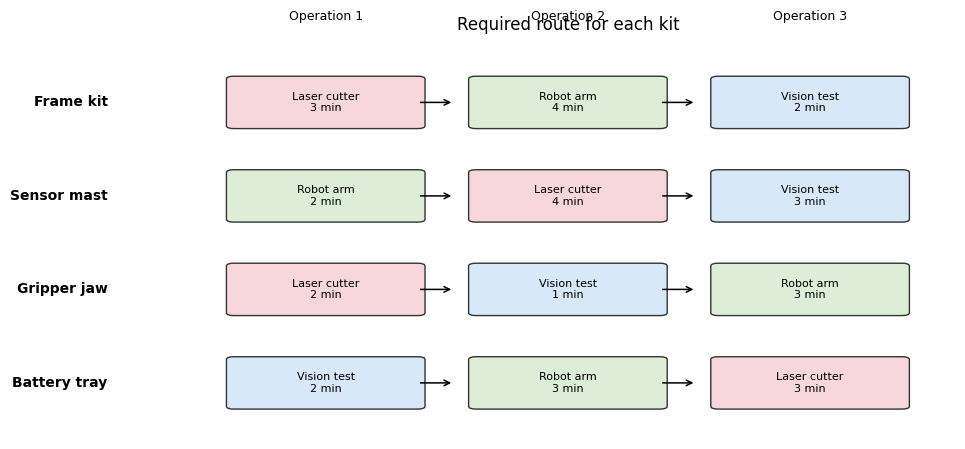

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


def plot_job_routes(jobs):
    station_colors = {
        "Laser cutter": "#F8D7DA",
        "Robot arm": "#DDEED8",
        "Vision test": "#D8E8F8",
    }

    job_names = list(jobs)
    max_operations = max(len(route) for route in jobs.values())
    fig, ax = plt.subplots(figsize=(10, 0.9 * len(job_names) + 1.5))
    ax.set_xlim(0.4, max_operations + 0.6)
    ax.set_ylim(-0.6, len(job_names) - 0.4)
    ax.axis("off")

    for y, job in enumerate(reversed(job_names)):
        ax.text(0.1, y, job, ha="right", va="center", fontsize=10, weight="bold")
        route = jobs[job]
        for operation, (station, duration) in enumerate(route, start=1):
            x = operation
            box = FancyBboxPatch(
                (x - 0.38, y - 0.25),
                0.76,
                0.5,
                boxstyle="round,pad=0.03",
                linewidth=1,
                edgecolor="#333333",
                facecolor=station_colors.get(station, "#EFEFEF"),
            )
            ax.add_patch(box)
            ax.text(x, y, f"{station}\n{duration} min", ha="center", va="center", fontsize=8)
            if operation < len(route):
                ax.annotate("", xy=(x + 0.53, y), xytext=(x + 0.38, y), arrowprops={"arrowstyle": "->", "lw": 1.1})

    for operation in range(1, max_operations + 1):
        ax.text(operation, len(job_names) - 0.15, f"Operation {operation}", ha="center", va="bottom", fontsize=9)

    ax.set_title("Required route for each kit", pad=12)
    return fig, ax


plot_job_routes(jobs);


## Warm-up: two jobs and two stations

Before building the general model, look at a tiny case by hand.

- Job A: `Station 1` for 5 minutes, then `Station 2` for 6 minutes.
- Job B: `Station 2` for 4 minutes, then `Station 1` for 7 minutes.

Questions:

1. Can both first operations start at time 0?
2. What must happen before Job A can use Station 2?
3. What must happen before Job B can use Station 1?
4. Draw a schedule manually. The optimal makespan is **12 minutes**.

The useful idea is this: on each station, either Job A goes before Job B or Job B goes before Job A. That either/or decision is what the binary variable represents.


In [3]:
warmup_jobs = {
    "Job A": [
        ("Station 1", 5),
        ("Station 2", 6),
    ],
    "Job B": [
        ("Station 2", 4),
        ("Station 1", 7),
    ],
}

warmup_rows = []
for job, route in warmup_jobs.items():
    for operation, (station, duration) in enumerate(route, start=1):
        warmup_rows.append({
            "job": job,
            "operation": operation,
            "station": station,
            "duration": duration,
        })

pd.DataFrame(warmup_rows)


,job,operation,station,duration
0,Job A,1,Station 1,5
1,Job A,2,Station 2,6
2,Job B,1,Station 2,4
3,Job B,2,Station 1,7


## Model idea

For every operation we create a start-time variable:

$$s_{j,k} \ge 0$$

where $j$ is the job and $k$ is the operation number inside that job.

The model has three groups of constraints.

### 1. Route order inside each job

If operation 2 of a job comes after operation 1, then operation 2 cannot start before operation 1 finishes:

$$s_{j,2} \ge s_{j,1} + p_{j,1}$$

### 2. No overlap on the same station

For two operations `a` and `b` that need the same station, exactly one must happen first. We use a binary variable $y_{a,b}$.

If $y_{a,b}=1$, operation `a` is before `b`. If $y_{a,b}=0$, operation `b` is before `a`.

The two Big-M constraints are:

$$s_b \ge s_a + p_a - M(1-y_{a,b})$$

$$s_a \ge s_b + p_b - My_{a,b}$$

The Big-M term is a switch. When one ordering is selected, one constraint is active and blocks overlap. The other constraint receives a large subtraction, so it becomes loose and does not restrict the schedule. $M$ must be large enough to relax the inactive constraint, but not absurdly large. Here we use the sum of all operation durations because that is a safe schedule horizon for this basic model: even a one-at-a-time schedule would finish by then. If you later add fixed release times, maintenance windows, or other constraints that can force idle time, increase the horizon so Big-M is still large enough.

### 3. Makespan

The makespan must be at least the finish time of every job's last operation:

$$C_{max} \ge s_{j,last} + p_{j,last}$$

The objective is:

$$\min C_{max}$$


In [4]:
from itertools import combinations
import re

import pulp


def _safe_name(text):
    """Create solver-friendly variable and constraint names."""
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(text)).strip("_")


def _operation_name(operation):
    job, index = operation
    return f"{_safe_name(job)}_op{index + 1}"


def solve_jobshop(jobs, msg=False, horizon=None):
    """Solve a small job-shop scheduling instance.

    Parameters
    ----------
    jobs : dict[str, list[tuple[str, int | float]]]
        Mapping from job name to an ordered route. Each route item is
        (station_name, processing_time).
    msg : bool
        Whether the solver should print its log.
    horizon : int | float | None
        Big-M value. If None, use the sum of all processing times.

    Returns
    -------
    makespan : float
    schedule : pandas.DataFrame
        Columns: job, operation, station, start, duration, finish.
    model : pulp.LpProblem
        The solved PuLP model, useful for inspection.
    """
    model = pulp.LpProblem("Robot_Cell_Job_Shop", pulp.LpMinimize)

    operations = [
        (job, operation_index)
        for job, route in jobs.items()
        for operation_index in range(len(route))
    ]
    station_of = {
        (job, operation_index): jobs[job][operation_index][0]
        for job, operation_index in operations
    }
    duration = {
        (job, operation_index): jobs[job][operation_index][1]
        for job, operation_index in operations
    }
    if horizon is None:
        horizon = sum(duration[operation] for operation in operations)

    start = {
        operation: pulp.LpVariable(
            f"start__{_operation_name(operation)}",
            lowBound=0,
            cat="Continuous",
        )
        for operation in operations
    }
    cmax = pulp.LpVariable("Cmax", lowBound=0, cat="Continuous")

    model += cmax, "minimize_makespan"

    # Route-order constraints: operations inside a job must follow the route.
    for job, route in jobs.items():
        for operation_index in range(len(route) - 1):
            current_operation = (job, operation_index)
            next_operation = (job, operation_index + 1)
            model += (
                start[next_operation] >= start[current_operation] + duration[current_operation],
                f"route__{_operation_name(current_operation)}__before__{_operation_name(next_operation)}",
            )

    # No-overlap constraints: two operations sharing a station cannot overlap.
    stations = sorted({station for route in jobs.values() for station, _ in route})
    for station in stations:
        station_operations = [operation for operation in operations if station_of[operation] == station]
        for first_operation, second_operation in combinations(station_operations, 2):
            order = pulp.LpVariable(
                f"order__{_safe_name(station)}__{_operation_name(first_operation)}__before__{_operation_name(second_operation)}",
                cat="Binary",
            )
            model += (
                start[second_operation]
                >= start[first_operation] + duration[first_operation] - horizon * (1 - order),
                f"no_overlap__{_safe_name(station)}__{_operation_name(first_operation)}__before__{_operation_name(second_operation)}",
            )
            model += (
                start[first_operation]
                >= start[second_operation] + duration[second_operation] - horizon * order,
                f"no_overlap__{_safe_name(station)}__{_operation_name(second_operation)}__before__{_operation_name(first_operation)}",
            )

    # Makespan constraints: Cmax must be after the final operation of every job.
    for job, route in jobs.items():
        last_operation = (job, len(route) - 1)
        model += (
            cmax >= start[last_operation] + duration[last_operation],
            f"makespan_after__{_safe_name(job)}",
        )

    solver = pulp.PULP_CBC_CMD(msg=msg)
    model.solve(solver)

    status = pulp.LpStatus[model.status]
    if status != "Optimal":
        raise RuntimeError(
            f"Solver status is {status}, not Optimal. "
            "Check whether the routes and no-overlap constraints are feasible. "
            "If you added release times or maintenance windows, also check that the horizon/Big-M value is large enough."
        )

    rows = []
    for job, route in jobs.items():
        for operation_index, (station, processing_time) in enumerate(route):
            operation = (job, operation_index)
            start_time = pulp.value(start[operation])
            if start_time is None:
                raise RuntimeError(
                    f"No start time was returned for {job}, operation {operation_index + 1}. "
                    "Check the solver status and model constraints."
                )
            rows.append({
                "job": job,
                "operation": operation_index + 1,
                "station": station,
                "start": start_time,
                "duration": processing_time,
                "finish": start_time + processing_time,
            })

    schedule = (
        pd.DataFrame(rows)
        .sort_values(["station", "start", "job"])
        .reset_index(drop=True)
    )
    return pulp.value(cmax), schedule, model


In [5]:
warmup_makespan, warmup_schedule, warmup_model = solve_jobshop(warmup_jobs)
print(f"Warm-up optimal makespan: {warmup_makespan:.0f} minutes")
print("Expected value for the original warm-up data: 12 minutes")
warmup_schedule


Warm-up optimal makespan: 12 minutes
Expected value for the original warm-up data: 12 minutes


,job,operation,station,start,duration,finish
0,Job A,1,Station 1,0.0,5,5.0
1,Job B,2,Station 1,5.0,7,12.0
2,Job B,1,Station 2,0.0,4,4.0
3,Job A,2,Station 2,5.0,6,11.0


In [6]:
makespan, schedule, model = solve_jobshop(jobs)
print(f"Robot-cell optimal makespan: {makespan:.0f} minutes")
print("Expected value for the original robot-cell data: 13 minutes")
schedule


Robot-cell optimal makespan: 13 minutes
Expected value for the original robot-cell data: 13 minutes


,job,operation,station,start,duration,finish
0,Frame kit,1,Laser cutter,0.0,3,3.0
1,Sensor mast,2,Laser cutter,3.0,4,7.0
2,Gripper jaw,1,Laser cutter,7.0,2,9.0
3,Battery tray,3,Laser cutter,10.0,3,13.0
4,Sensor mast,1,Robot arm,0.0,2,2.0
5,Frame kit,2,Robot arm,3.0,4,7.0
6,Battery tray,2,Robot arm,7.0,3,10.0
7,Gripper jaw,3,Robot arm,10.0,3,13.0
8,Battery tray,1,Vision test,0.0,2,2.0
9,Frame kit,3,Vision test,7.0,2,9.0


## Validate before plotting

A Gantt chart helps us see the schedule, but first check the rules automatically.

A valid schedule must satisfy two things:

1. every job follows its operation route,
2. operations on the same station do not overlap.


In [7]:
def validate_schedule(jobs, schedule, tolerance=1e-7):
    """Check route-order and no-overlap rules for a computed schedule."""
    indexed = {
        (row.job, int(row.operation) - 1): row
        for row in schedule.itertuples(index=False)
    }

    for job, route in jobs.items():
        for operation_index in range(len(route) - 1):
            current_operation = indexed[(job, operation_index)]
            next_operation = indexed[(job, operation_index + 1)]
            if next_operation.start + tolerance < current_operation.finish:
                raise AssertionError(
                    f"Route violation for {job}: operation {operation_index + 2} "
                    f"starts before operation {operation_index + 1} finishes."
                )

    for station, station_schedule in schedule.groupby("station"):
        ordered = station_schedule.sort_values("start")
        previous_operation = None
        for operation in ordered.itertuples(index=False):
            if (
                previous_operation is not None
                and operation.start + tolerance < previous_operation.finish
            ):
                raise AssertionError(
                    f"Overlap on {station}: {previous_operation.job} and {operation.job}."
                )
            previous_operation = operation

    return "Schedule is valid."


validate_schedule(warmup_jobs, warmup_schedule), validate_schedule(jobs, schedule)


('Schedule is valid.', 'Schedule is valid.')

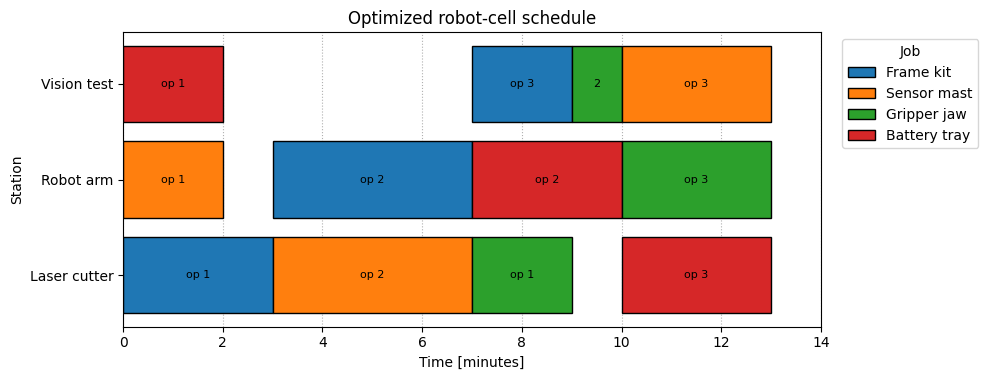

In [8]:
import matplotlib.pyplot as plt


def plot_gantt(schedule, title="Optimized robot-cell schedule"):
    """Plot a Gantt chart from a schedule DataFrame."""
    stations = list(schedule["station"].drop_duplicates())
    jobs_in_schedule = list(schedule["job"].drop_duplicates())
    y_position = {station: index for index, station in enumerate(stations)}
    color_map = {
        job: plt.get_cmap("tab10")(index % 10)
        for index, job in enumerate(jobs_in_schedule)
    }

    fig_height = max(3.5, 0.8 * len(stations) + 1.5)
    fig, ax = plt.subplots(figsize=(10, fig_height))
    labelled_jobs = set()

    for row in schedule.itertuples(index=False):
        y = y_position[row.station]
        label = row.job if row.job not in labelled_jobs else None
        labelled_jobs.add(row.job)

        ax.barh(
            y,
            row.duration,
            left=row.start,
            color=color_map[row.job],
            edgecolor="black",
            label=label,
        )
        operation_label = f"op {int(row.operation)}" if row.duration >= 1.8 else str(int(row.operation))
        ax.text(
            row.start + row.duration / 2,
            y,
            operation_label,
            ha="center",
            va="center",
            fontsize=8,
        )

    ax.set_yticks(list(y_position.values()))
    ax.set_yticklabels(list(y_position.keys()))
    ax.set_xlabel("Time [minutes]")
    ax.set_ylabel("Station")
    ax.set_title(title)
    ax.set_xlim(0, schedule["finish"].max() + 1)
    ax.grid(axis="x", linestyle=":")
    ax.set_axisbelow(True)
    ax.legend(title="Job", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    return fig, ax


plot_gantt(schedule);


## Student tasks

### Task 1: identify the optimization objects

Fill in the blanks:

- Jobs are: `__________`
- Stations are: `__________`
- Decision variables are: `__________`
- The objective is: `__________`
- The two main constraint families are: `__________`

### Task 2: modify the data

The robot arm gets a faster gripper, so every **Robot arm** operation is 1 minute shorter, but never below 1 minute. Re-solve the model. How much does the makespan improve?

### Task 3: bottleneck analysis

Using the Gantt chart, answer:

- Which station is busiest?
- Which station has the most idle time?
- Which job finishes last?
- Is the last-finishing job necessarily the bottleneck? Explain.

### Task 4: add a maintenance window

The vision test station is unavailable from time 4 to time 6. Extend the model so no vision-test operation can overlap that interval.

Hint: this is another either/or decision. For each vision-test operation, it must finish before minute 4 or start after minute 6.

### Challenge: due dates

Suppose visitors care most about the `Frame kit`, which has a due date at minute 10. Add a tardiness variable.

A completion time $C_j$ tells us when job $j$ finishes. A due date $d_j$ tells us when it should finish. Tardiness is the delay after the due date:

$$T_j \ge C_j - d_j$$

Also add $T_j \ge 0$, because finishing early should give zero tardiness, not a negative penalty. For the `Frame kit`, if it finishes at minute 13 and the due date is minute 10, then $T_j=3$.

Then solve either:

- minimize makespan first, then tardiness,
- or minimize `makespan + 0.5 * total_tardiness`.


## Solutions

### Task 1 — identify the optimization objects

- **Jobs** are the four kits: `Frame kit`, `Sensor mast`, `Gripper jaw`, `Battery tray`. Each job has a fixed route of operations.
- **Stations** (machines) are `Laser cutter`, `Robot arm`, `Vision test`. Each station can process one operation at a time.
- **Decision variables** are:
  - `start[(job, op)]` — continuous, the start time of every operation,
  - `order[(station, op_a, op_b)]` — binary, **1** if `op_a` runs before `op_b` on that station, **0** otherwise,
  - `Cmax` — the makespan (continuous).
- **Objective:** minimize `Cmax`.
- **Two main constraint families:**
  1. **Route order** (precedence): inside a job, operation k+1 cannot start before operation k finishes.
  2. **No-overlap on each station** (disjunctive Big-M): two operations sharing a station cannot overlap; the binary `order` variable picks which one is first.


Original durations:


operation,1,2,3
job,,,
Battery tray,2,3,3
Frame kit,3,4,2
Gripper jaw,2,1,3
Sensor mast,2,4,3


Sped-up durations:


operation,1,2,3
job,,,
Battery tray,2,2,3
Frame kit,3,3,2
Gripper jaw,2,1,2
Sensor mast,1,4,3



Original makespan:  13 minutes
Sped-up makespan:    12 minutes
Improvement:         1 minutes (7.7%)


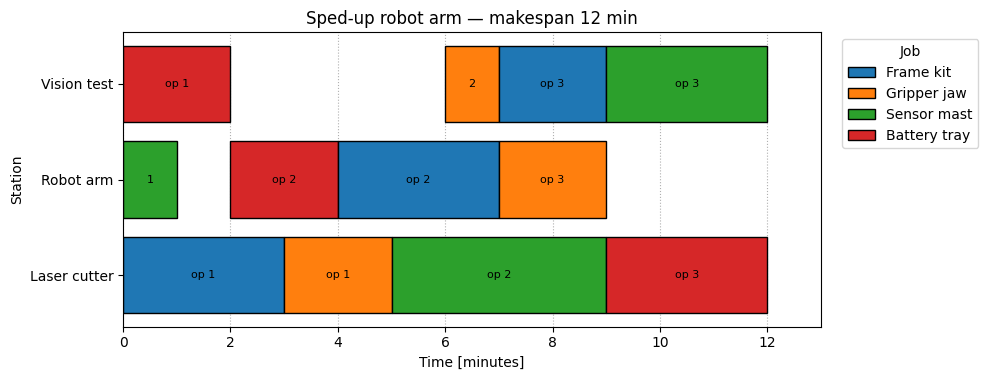

In [9]:
# Task 2 SOLUTION -- a faster gripper makes every Robot-arm operation 1 minute shorter
#                    (but never below 1 minute).

def speed_up_robot_arm(jobs, station_name="Robot arm", saved_minutes=1, min_duration=1):
    """Return a copy of `jobs` with `station_name` operations sped up."""
    return {
        job: [
            (station, max(min_duration, duration - saved_minutes) if station == station_name else duration)
            for station, duration in route
        ]
        for job, route in jobs.items()
    }


jobs_faster = speed_up_robot_arm(jobs)

# Compare the two route tables side by side
import pandas as pd
old_rows, new_rows = [], []
for job in jobs:
    for k, (s, d) in enumerate(jobs[job], start=1):
        old_rows.append({"job": job, "operation": k, "station": s, "duration": d})
    for k, (s, d) in enumerate(jobs_faster[job], start=1):
        new_rows.append({"job": job, "operation": k, "station": s, "duration": d})
print("Original durations:")
display(pd.DataFrame(old_rows).pivot(index="job", columns="operation", values="duration"))
print("Sped-up durations:")
display(pd.DataFrame(new_rows).pivot(index="job", columns="operation", values="duration"))

faster_makespan, faster_schedule, _ = solve_jobshop(jobs_faster)
print(f"\nOriginal makespan:  {makespan:.0f} minutes")
print(f"Sped-up makespan:    {faster_makespan:.0f} minutes")
print(f"Improvement:         {makespan - faster_makespan:.0f} minutes "
      f"({(makespan - faster_makespan)/makespan*100:.1f}%)")

validate_schedule(jobs_faster, faster_schedule)
plot_gantt(faster_schedule, title=f"Sped-up robot arm — makespan {faster_makespan:.0f} min");


**Task 2 interpretation.** Cutting 1 minute off each Robot-arm operation removes 4 minutes of work overall (one per job), but the makespan only drops if the critical path passes through the robot arm. If the bottleneck is elsewhere, much of the saving is absorbed as idle time on the robot arm rather than as a shorter schedule.


In [10]:
# Task 3 SOLUTION -- station utilisation and the bottleneck

def station_utilisation(schedule, makespan):
    """Compute busy time, idle time and utilisation per station."""
    rows = []
    for station, sub in schedule.groupby("station"):
        busy = float(sub["duration"].sum())
        idle = makespan - busy
        rows.append({
            "station": station,
            "busy_min": busy,
            "idle_min": idle,
            "utilisation_%": round(100 * busy / makespan, 1),
        })
    return pd.DataFrame(rows).sort_values("utilisation_%", ascending=False).reset_index(drop=True)


utilisation = station_utilisation(schedule, makespan)
display(utilisation)

# Identify the job that finishes last
last_finish = schedule.groupby("job")["finish"].max().sort_values(ascending=False)
print("\nFinish time of the last operation of each job:")
display(last_finish)
print(f"Last-finishing job: {last_finish.idxmax()} at minute {last_finish.iloc[0]:.0f}")


,station,busy_min,idle_min,utilisation_%
0,Laser cutter,12.0,1.0,92.3
1,Robot arm,12.0,1.0,92.3
2,Vision test,8.0,5.0,61.5



Finish time of the last operation of each job:


job
Battery tray    13.0
Gripper jaw     13.0
Sensor mast     13.0
Frame kit        9.0
Name: finish, dtype: float64

Last-finishing job: Battery tray at minute 13


**Task 3 interpretation.**

- **Busiest station** = highest utilisation in the table above (the bottleneck candidate).
- **Most idle time** = lowest utilisation.
- **Last-finishing job** is whichever job's final operation finishes at `Cmax`.
- Is the last-finishing job *necessarily* the bottleneck? **No.** The makespan is determined by the **critical path**, which is a chain of operations across jobs and stations. A job can be last simply because it was queued behind others on the busy station, even though the bottleneck is that station — not the job. The station with highest utilisation is the better bottleneck signal.


Makespan with Vision-test maintenance 4..6: 13 minutes
Makespan WITHOUT maintenance:               13 minutes
Penalty paid for the maintenance window:    0 minutes

All Vision-test operations respect the maintenance window 4..6.


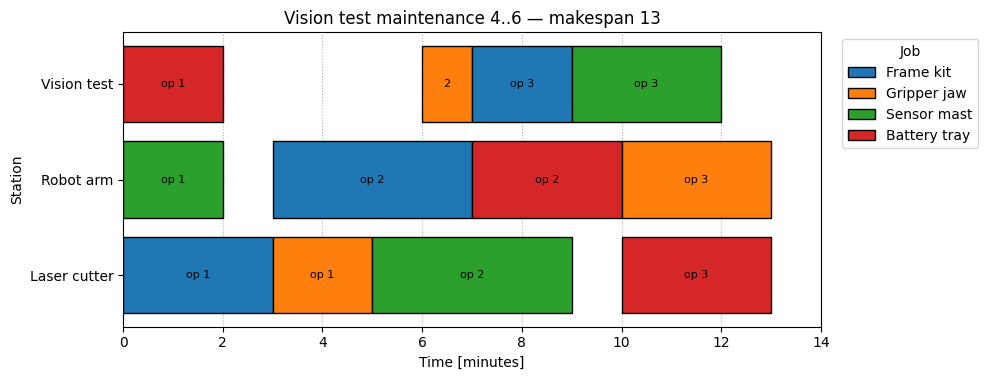

In [11]:
# Task 4 SOLUTION -- the Vision test station is unavailable from time 4 to time 6.
# Each Vision-test operation must finish BEFORE 4, or START AFTER 6.

from itertools import combinations
import pulp
import re


def _safe(text):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(text)).strip("_")


def solve_jobshop_with_maintenance(jobs, station_name, window_start, window_end, msg=False):
    """Job-shop scheduler with one maintenance window on a single station.

    For each operation on `station_name`, exactly one of these must hold:
      (a) s + p <= window_start   -- operation finishes before maintenance
      (b) s >= window_end         -- operation starts after maintenance
    We model the either/or with a binary z and Big-M.
    """
    operations = [(j, k) for j, route in jobs.items() for k in range(len(route))]
    station_of = {(j, k): jobs[j][k][0] for j, k in operations}
    duration   = {(j, k): jobs[j][k][1] for j, k in operations}
    horizon = sum(duration.values()) + window_end  # safe upper bound

    m = pulp.LpProblem("Job_Shop_with_Maintenance", pulp.LpMinimize)
    start = {op: pulp.LpVariable(f"s_{_safe(op[0])}_{op[1]}", lowBound=0) for op in operations}
    Cmax  = pulp.LpVariable("Cmax", lowBound=0)
    m += Cmax

    # Route precedence
    for j, route in jobs.items():
        for k in range(len(route) - 1):
            m += start[(j, k + 1)] >= start[(j, k)] + duration[(j, k)]

    # No overlap on each station
    stations = sorted({s for r in jobs.values() for s, _ in r})
    for st in stations:
        st_ops = [op for op in operations if station_of[op] == st]
        for a, b in combinations(st_ops, 2):
            y = pulp.LpVariable(f"y_{_safe(st)}_{_safe(a[0])}_{a[1]}__{_safe(b[0])}_{b[1]}", cat="Binary")
            m += start[b] >= start[a] + duration[a] - horizon * (1 - y)
            m += start[a] >= start[b] + duration[b] - horizon * y

    # Makespan
    for j, route in jobs.items():
        last = (j, len(route) - 1)
        m += Cmax >= start[last] + duration[last]

    # Maintenance window on station_name: for each op on that station,
    # finish before window_start OR start at/after window_end.
    for op in operations:
        if station_of[op] != station_name:
            continue
        z = pulp.LpVariable(f"after_maint_{_safe(op[0])}_{op[1]}", cat="Binary")
        # z = 0: op must finish by window_start
        # z = 1: op must start at or after window_end
        m += start[op] + duration[op] <= window_start + horizon * z
        m += start[op] >= window_end - horizon * (1 - z)

    m.solve(pulp.PULP_CBC_CMD(msg=msg))
    if pulp.LpStatus[m.status] != "Optimal":
        raise RuntimeError(f"Solver status: {pulp.LpStatus[m.status]}")

    rows = []
    for j, route in jobs.items():
        for k, (st, p) in enumerate(route):
            s = pulp.value(start[(j, k)])
            rows.append({"job": j, "operation": k + 1, "station": st,
                         "start": s, "duration": p, "finish": s + p})
    return pulp.value(Cmax), pd.DataFrame(rows).sort_values(["station", "start", "job"]).reset_index(drop=True), m


maint_makespan, maint_schedule, _ = solve_jobshop_with_maintenance(
    jobs, station_name="Vision test", window_start=4, window_end=6,
)
print(f"Makespan with Vision-test maintenance 4..6: {maint_makespan:.0f} minutes")
print(f"Makespan WITHOUT maintenance:               {makespan:.0f} minutes")
print(f"Penalty paid for the maintenance window:    {maint_makespan - makespan:.0f} minutes\n")

validate_schedule(jobs, maint_schedule)

# Quick sanity check: no Vision-test op overlaps the (4, 6) window.
vt = maint_schedule[maint_schedule["station"] == "Vision test"]
for r in vt.itertuples(index=False):
    assert r.finish <= 4 + 1e-7 or r.start >= 6 - 1e-7, f"Vision test op overlaps maintenance: {r}"
print("All Vision-test operations respect the maintenance window 4..6.")

plot_gantt(maint_schedule, title=f"Vision test maintenance 4..6 — makespan {maint_makespan:.0f}");


**Task 4 explanation.** A maintenance window is another *disjunctive* constraint: each affected operation lives **either** entirely before the window **or** entirely after it — never overlapping. We add one binary `after_maint` per Vision-test operation and a Big-M pair of constraints, just like the no-overlap rule between two operations.


Makespan with due-date weighting:  13 minutes
Tardiness per job:                  {'Frame kit': 0.0}
Original makespan (no due dates):  13 minutes

Frame kit finishes at minute 9; due date is minute 10.
Tardiness = max(0, 9 - 10) = 0.


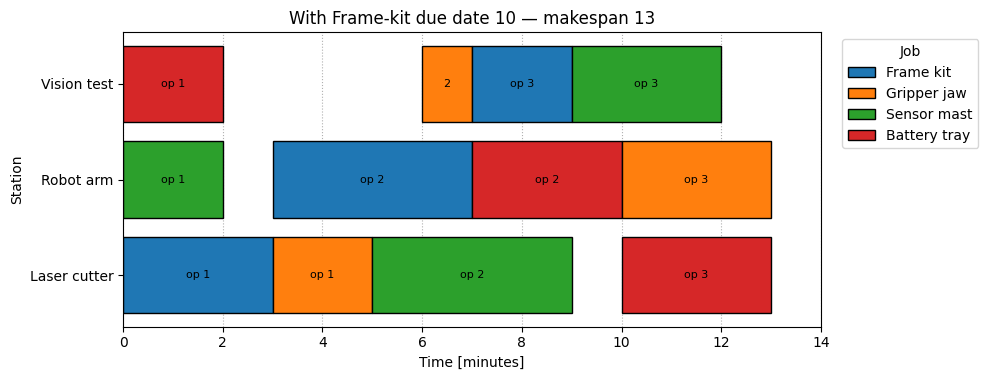

In [12]:
# CHALLENGE SOLUTION -- minimize makespan + 0.5 * total_tardiness
# Frame kit has a due date at minute 10.

from itertools import combinations
import pulp
import re


def _safe(text):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(text)).strip("_")


def solve_jobshop_with_duedates(jobs, due_dates, weight_tardiness=0.5, msg=False):
    operations = [(j, k) for j, route in jobs.items() for k in range(len(route))]
    duration   = {(j, k): jobs[j][k][1] for j, k in operations}
    station_of = {(j, k): jobs[j][k][0] for j, k in operations}
    horizon = sum(duration.values())

    m = pulp.LpProblem("Job_Shop_with_DueDates", pulp.LpMinimize)
    start = {op: pulp.LpVariable(f"s_{_safe(op[0])}_{op[1]}", lowBound=0) for op in operations}
    Cmax  = pulp.LpVariable("Cmax", lowBound=0)
    T     = {j: pulp.LpVariable(f"T_{_safe(j)}", lowBound=0) for j in due_dates}

    m += Cmax + weight_tardiness * pulp.lpSum(T.values())

    for j, route in jobs.items():
        for k in range(len(route) - 1):
            m += start[(j, k + 1)] >= start[(j, k)] + duration[(j, k)]

    stations = sorted({s for r in jobs.values() for s, _ in r})
    for st in stations:
        st_ops = [op for op in operations if station_of[op] == st]
        for a, b in combinations(st_ops, 2):
            y = pulp.LpVariable(f"y_{_safe(st)}_{_safe(a[0])}_{a[1]}__{_safe(b[0])}_{b[1]}", cat="Binary")
            m += start[b] >= start[a] + duration[a] - horizon * (1 - y)
            m += start[a] >= start[b] + duration[b] - horizon * y

    for j, route in jobs.items():
        last = (j, len(route) - 1)
        m += Cmax >= start[last] + duration[last]

    # Tardiness: T_j >= C_j - d_j, with T_j >= 0 (already from lowBound)
    for j, due in due_dates.items():
        last = (j, len(jobs[j]) - 1)
        m += T[j] >= (start[last] + duration[last]) - due

    m.solve(pulp.PULP_CBC_CMD(msg=msg))
    assert pulp.LpStatus[m.status] == "Optimal"

    rows = []
    for j, route in jobs.items():
        for k, (st, p) in enumerate(route):
            s = pulp.value(start[(j, k)])
            rows.append({"job": j, "operation": k + 1, "station": st,
                         "start": s, "duration": p, "finish": s + p})
    sched = pd.DataFrame(rows).sort_values(["station", "start", "job"]).reset_index(drop=True)
    tardiness = {j: round(pulp.value(T[j]), 3) for j in due_dates}
    return pulp.value(Cmax), tardiness, sched, m


due_dates = {"Frame kit": 10}
dd_makespan, dd_tardiness, dd_schedule, _ = solve_jobshop_with_duedates(jobs, due_dates)

print(f"Makespan with due-date weighting:  {dd_makespan:.0f} minutes")
print(f"Tardiness per job:                  {dd_tardiness}")
print(f"Original makespan (no due dates):  {makespan:.0f} minutes\n")

# What is the Frame kit's actual finish time?
frame_finish = dd_schedule[dd_schedule["job"] == "Frame kit"]["finish"].max()
print(f"Frame kit finishes at minute {frame_finish:.0f}; due date is minute 10.")
print(f"Tardiness = max(0, {frame_finish:.0f} - 10) = {max(0, frame_finish - 10):.0f}.")

validate_schedule(jobs, dd_schedule)
plot_gantt(dd_schedule, title=f"With Frame-kit due date 10 — makespan {dd_makespan:.0f}");


**Challenge explanation.** Tardiness `T_j = max(0, C_j - d_j)` is modelled with a non-negative continuous variable and the linear lower bound `T_j >= C_j - d_j`. The `lowBound=0` on `T_j` enforces the "early finish ⇒ zero tardiness, not negative" rule. Combining it with the makespan in a single weighted objective — `Cmax + 0.5 * sum(T_j)` — gives a Pareto trade-off: the optimizer pushes the priority job's last operation toward its due date as long as the gain in tardiness outweighs the extra makespan.
